导入数据

In [1]:
import json

DATA_INFO_PATH = r"C:/Users/yyy/Desktop/course project/BCIC2A/dataset_info_fixed.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

=== Dataset Intro ===
Categories: ['left', 'right', 'foot', 'tongue']
Channels (count): 22
Channels: ['FZ', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'P1', 'PZ', 'P2', 'POZ']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 1.0


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。

In [2]:
import h5py
import numpy as np
DATA_NAME = "BCIC2A"
INDEX_PATH_TRAIN = r"C:/Users/yyy/Desktop/course project/BCIC2A/train.h5"
INDEX_PATH_VAL = r"C:/Users/yyy/Desktop/course project/BCIC2A/val.h5"
INDEX_PATH_TEST = r"C:/Users/yyy/Desktop/course project/BCIC2A/test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    print(INDEX_PATH_TEST)

keys: ['X', 'y']
x dtype: float32
x shape: (720, 22, 800)
y dtype: int64
y shape: (720,)
unique: [0 1 2 3]
C:/Users/yyy/Desktop/course project/BCIC2A/test_x_only.h5


In [3]:
import os

print(os.path.exists(INDEX_PATH_TEST))
print(os.path.getsize(INDEX_PATH_TEST))

True
25346048


## 模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline

In [4]:
import torch
import torch.nn as nn


class EEGNet(nn.Module):
    def __init__(
        self,
        chans,
        time_point=800,
        num_classes=4,
        f1=8,
        d=2,
        pk1=4,
        pk2=8,
        dp=0.5,
        max_norm1=1,
        norm=nn.Identity()
    ):
        super().__init__()

        f2 = f1 * d
        self.norm = norm

        # Temporal Convolution
        self.block1 = nn.Sequential(
            nn.Conv2d(
                1, f1,
                kernel_size=(1, 64),
                padding=(0, 32),
                bias=False
            ),
            nn.BatchNorm2d(f1)
        )

        # Depthwise Spatial Convolution
        self.block2 = nn.Sequential(
            nn.Conv2d(
                f1,
                d * f1,
                kernel_size=(chans, 1),
                groups=f1,
                bias=False
            ),
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )

        # Separable Convolution
        self.block3 = nn.Sequential(
            nn.Conv2d(
                d * f1,
                f2,
                kernel_size=(1, 16),
                groups=f2,
                padding=(0, 8),
                bias=False
            ),
            nn.Conv2d(
                f2,
                f2,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        # Max norm
        self._apply_max_norm(self.block2[0], max_norm1)

        # 自动计算特征维度
        with torch.no_grad():
            dummy = torch.zeros(1, chans, time_point)  # (B, C, T)
            dummy = self._forward_features(dummy)
            self.embed_dim = dummy.shape[1]

        print("EEGNet embed_dim =", self.embed_dim)

        # 分类层
        self.classifier = nn.Linear(self.embed_dim, num_classes)

    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if "weight" in name:
                param.data = torch.renorm(
                    param.data,
                    p=2,
                    dim=0,
                    maxnorm=max_norm
                )

    def _forward_features(self, x):
        """
        x: (B, C, T)
        """
        x = self.norm(x)

        # 如果输入单个样本 (C, T)
        if x.dim() == 2:
            x = x.unsqueeze(0)

        # (B, C, T) -> (B, 1, C, T)
        x = x.unsqueeze(1)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = x.flatten(start_dim=1)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = self.classifier(x)
        return x

## 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。

EEGNet embed_dim = 400
Epoch [001/300] | Train Loss: 1.4414 | Train Acc: 0.2556 | Val Loss: 1.3856 | Val Acc: 0.3056 | LR: 0.000300
✅ Best model updated at epoch 1
Epoch [002/300] | Train Loss: 1.4206 | Train Acc: 0.2569 | Val Loss: 1.3726 | Val Acc: 0.3222 | LR: 0.000300
✅ Best model updated at epoch 2
Epoch [003/300] | Train Loss: 1.3990 | Train Acc: 0.2875 | Val Loss: 1.3613 | Val Acc: 0.3528 | LR: 0.000300
✅ Best model updated at epoch 3
Epoch [004/300] | Train Loss: 1.4086 | Train Acc: 0.2528 | Val Loss: 1.3563 | Val Acc: 0.3722 | LR: 0.000300
✅ Best model updated at epoch 4
Epoch [005/300] | Train Loss: 1.3817 | Train Acc: 0.2833 | Val Loss: 1.3520 | Val Acc: 0.4028 | LR: 0.000300
✅ Best model updated at epoch 5
Epoch [006/300] | Train Loss: 1.3997 | Train Acc: 0.2736 | Val Loss: 1.3496 | Val Acc: 0.3861 | LR: 0.000300
EarlyStopping Counter: 1/50
Epoch [007/300] | Train Loss: 1.3743 | Train Acc: 0.3139 | Val Loss: 1.3441 | Val Acc: 0.4056 | LR: 0.000300
✅ Best model updated at ep

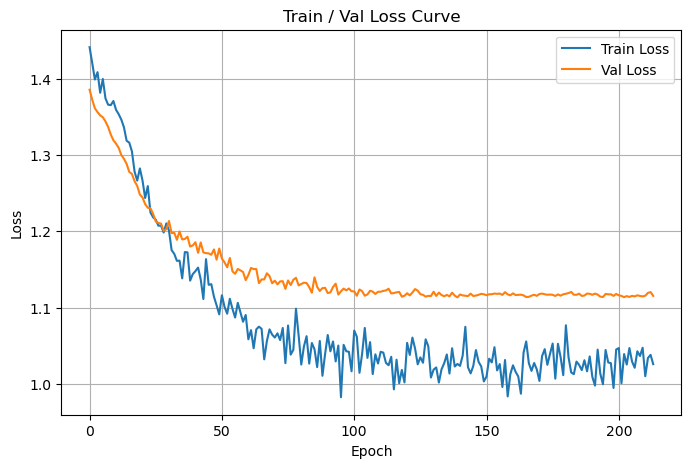

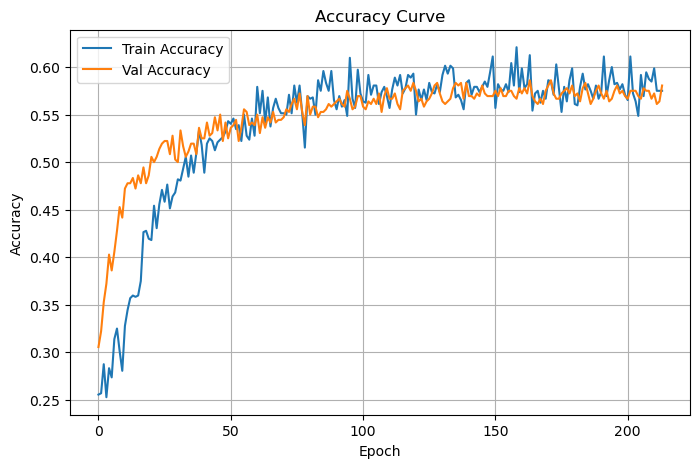

--------------------------------------------------
Test input shape : torch.Size([1, 22, 800])
Test output shape: torch.Size([1, 4])
Predicted class  : 3


In [10]:
import h5py
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from TEST_DATASET import TrainDataset, TestDataset


# =====================================================
# 固定随机种子
# =====================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 让结果更稳定
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)


# =====================================================
# 训练增强：随机时间平移
# =====================================================
def random_time_shift(x, max_shift=25):
    """
    x shape: (B, C, T)

    max_shift=25 表示最多平移 25 个采样点。
    如果采样率是 250 Hz，大约等于 0.1 秒。
    只用于训练集，不用于 val/test。
    """
    shift = random.randint(-max_shift, max_shift)

    if shift == 0:
        return x

    x_shifted = torch.zeros_like(x)

    if shift > 0:
        x_shifted[:, :, shift:] = x[:, :, :-shift]
    else:
        x_shifted[:, :, :shift] = x[:, :, -shift:]

    return x_shifted


# =====================================================
# 参数
# =====================================================
CHANNELS = 22
CLASSES = 4

BATCH_SIZE = 32
EPOCHS = 300

LR = 3e-4
WEIGHT_DECAY = 3e-3

PATIENCE = 50
MIN_DELTA = 0.001

LR_PATIENCE = 8
LR_FACTOR = 0.5
MIN_LR = 1e-6

MAX_NORM = 0.5


# =====================================================
# 数据
# =====================================================
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)


# =====================================================
# EEG 标准化：只用 train 统计量
# =====================================================
mean = train_ds.x.mean(dim=(0, 2), keepdim=True)
std = train_ds.x.std(dim=(0, 2), keepdim=True) + 1e-6

train_ds.x = (train_ds.x - mean) / std
val_ds.x = (val_ds.x - mean) / std
test_ds.x = (test_ds.x - mean) / std


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False
)


# =====================================================
# 模型
# =====================================================
model = EEGNet(
    chans=CHANNELS,
    time_point=800,
    num_classes=CLASSES,
    f1=8,
    d=2,
    pk1=4,
    pk2=8,
    dp=0.6
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)


# =====================================================
# Loss
# =====================================================
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.02
)


# =====================================================
# Optimizer
# =====================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


# =====================================================
# Scheduler
# =====================================================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR
)


# =====================================================
# 记录
# =====================================================
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0.0
best_epoch = 0
early_stop_counter = 0
best_model_state = copy.deepcopy(model.state_dict())


# =====================================================
# 训练循环
# =====================================================
for epoch in range(EPOCHS):

    # =================================================
    # Train
    # =================================================
    model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_num = 0

    for data, label in train_loader:

        data = data.to(device)
        label = label.to(device)

        # 只对训练集做随机时间平移增强
        data = random_time_shift(
            data,
            max_shift=25
        )

        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, label)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        # 关键：每次更新后重新做 MaxNorm
        with torch.no_grad():
            model._apply_max_norm(
                model.block2[0],
                max_norm=MAX_NORM
            )

        batch_size = label.size(0)

        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        pred = torch.argmax(output, dim=1)

        train_correct += (
            pred == label
        ).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # =================================================
    # Validation
    # =================================================
    model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():

        for val_data, val_label in val_loader:

            val_data = val_data.to(device)
            val_label = val_label.to(device)

            val_output = model(val_data)

            val_loss = criterion(
                val_output,
                val_label
            )

            batch_size = val_label.size(0)

            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(
                val_output,
                dim=1
            )

            val_correct += (
                val_pred == val_label
            ).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # 监控 Val Acc
    scheduler.step(epoch_val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    # =================================================
    # Early Stopping：监控 Val Acc
    # =================================================
    if epoch_val_acc > best_val_acc + MIN_DELTA:

        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"✅ Best model updated at epoch {best_epoch}"
        )

    else:

        early_stop_counter += 1

        print(
            f"EarlyStopping Counter: "
            f"{early_stop_counter}/{PATIENCE}"
        )

        if early_stop_counter >= PATIENCE:

            print("\n🛑 Early Stopping Triggered!")
            break


# =====================================================
# 加载最佳模型
# =====================================================
model.load_state_dict(best_model_state)


# =====================================================
# 输出结果
# =====================================================
print("\n" + "=" * 60)
print(f"Best Epoch        : {best_epoch}")
print(f"Best Val Accuracy : {best_val_acc:.4f}")
print("=" * 60)


# =====================================================
# Loss 曲线
# =====================================================
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# Accuracy 曲线
# =====================================================
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# Test 单个样本推理检查
# =====================================================
model.eval()

with torch.no_grad():

    test_data = next(iter(test_loader))
    test_data = test_data.to(device)

    test_pred = model(test_data)

    pred_class = torch.argmax(
        test_pred,
        dim=1
    )

    print("-" * 50)
    print("Test input shape :", test_data.shape)
    print("Test output shape:", test_pred.shape)
    print("Predicted class  :", pred_class.item())

## 绘图（loss/acc/混淆矩阵）

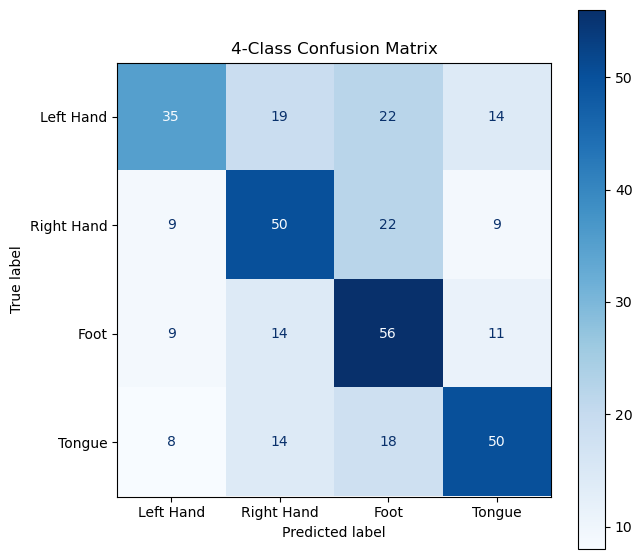


Classification Report:

              precision    recall  f1-score   support

   Left Hand     0.5738    0.3889    0.4636        90
  Right Hand     0.5155    0.5556    0.5348        90
        Foot     0.4746    0.6222    0.5385        90
      Tongue     0.5952    0.5556    0.5747        90

    accuracy                         0.5306       360
   macro avg     0.5398    0.5306    0.5279       360
weighted avg     0.5398    0.5306    0.5279       360

--------------------------------------------------
Test input shape : torch.Size([1, 22, 800])
Test output shape: torch.Size([1, 4])
Predicted class  : 3


In [6]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
# =====================================================
# 混淆矩阵
# =====================================================
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for val_data, val_label in val_loader:

        val_data = val_data.to(device)
        val_label = val_label.to(device)

        val_output = model(val_data)

        val_pred = torch.argmax(
            val_output,
            dim=1
        )

        all_preds.extend(
            val_pred.cpu().numpy()
        )

        all_labels.extend(
            val_label.cpu().numpy()
        )


cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=[0,1,2,3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Left Hand",
        "Right Hand",
        "Foot",
        "Tongue"
    ]
)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(
    cmap="Blues",
    values_format='d',
    ax=ax
)

plt.title("4-Class Confusion Matrix")

plt.show()


# =====================================================
# Classification Report
# =====================================================
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Left Hand",
            "Right Hand",
            "Foot",
            "Tongue"
        ],
        digits=4
    )
)


# =====================================================
# Test 推理
# =====================================================
model.eval()

with torch.no_grad():

    test_data = next(iter(test_loader))

    test_data = test_data.to(device)

    test_output = model(test_data)

    test_pred = torch.argmax(
        test_output,
        dim=1
    )

print("-" * 50)

print("Test input shape :", test_data.shape)

print("Test output shape:", test_output.shape)

print("Predicted class  :", test_pred.item())

## 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。

In [13]:
# =====================================================
# 保存 test 预测标签：每行一个数字
# =====================================================
model.eval()

output_path = r"C:/Users/yyy/Desktop/course project/BCIC2A/BCIC2A.txt"

all_test_labels = []

with torch.no_grad():

    for test_data in test_loader:

        test_data = test_data.to(device)

        test_output = model(test_data)

        test_pred = torch.argmax(
            test_output,
            dim=1
        )

        all_test_labels.extend(
            test_pred.cpu().tolist()
        )

with open(output_path, "w", encoding="utf-8") as f:

    for label in all_test_labels:

        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")


Saved 360 labels to: C:/Users/yyy/Desktop/course project/BCIC2A/BCIC2A.txt
